# 01 — SOLETE dataset overview

This notebook is the first thing to run if you're new to **SOLETE**: a 15-month,
hourly-and-finer dataset of co-located meteorology, wind power, and solar PV power
from a test site (SYSLAB) at DTU, Denmark. It replaces `RunMe.py` as the quickstart —
same idea (load the data, plot a bit of it), but explained as you go.

We'll use a small sample cut from the real 15-month file (`SOLETE_sample.h5`, ~90 days —
see `SAMPLE_DATA.md` for exactly why this window was chosen), loaded through the
project's real entry point rather than a bare `pd.read_hdf`, so you see the dataset the
way the rest of the codebase (`MLForecasting.py`) actually sees it.

In [1]:
import sys
sys.path.insert(0, '..')  # so `import Functions` works when running from examples/

import pandas as pd
import matplotlib.pyplot as plt

from Functions import import_SOLETE_data, import_SOLETE_sample, import_PV_WT_data

pd.set_option('display.max_columns', None)
%matplotlib inline

I0000 00:00:1789171349.045190     264 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789171349.084799     264 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1789171350.433386     264 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Loading the data: `Control_Var` and the two info dicts

SOLETE is loaded through `import_SOLETE_data()` (or, for this small sample,
`import_SOLETE_sample()` — a thin Phase 3 wrapper around the same logic, since the
sample file doesn't follow the `SOLETE_Pombo_<resolution>.h5` naming the full-size
loader expects). Both need two things:

- **`Control_Var`** — a single settings dict used everywhere in this codebase. For
  loading purposes, the only two keys that matter here are `'OriginalFeatures'`
  (filled in automatically — leave it as an empty list) and `'PossibleFeatures'`
  (a list of *extra* derived features you want computed on top of the raw columns,
  e.g. `'HoursOfDay'` or a rolling mean — leave it empty for now, we just want the
  raw + QC-flag columns).
- **`PVinfo` / `WTinfo`** — physical parameters of the actual PV array and wind
  turbine at the site (panel efficiency curve, turbine power curve, nameplate
  ratings, etc.), used by the PV performance model that runs during loading.

In [2]:
Control_Var = {
    'OriginalFeatures': [],   # filled in by the loader
    'PossibleFeatures': [],   # no extra derived features for this overview
}

PVinfo, WTinfo = import_PV_WT_data()
df = import_SOLETE_sample('../SOLETE_sample.h5', Control_Var, PVinfo, WTinfo)

SOLETE sample was imported from: ../SOLETE_sample.h5
    2160 rows, 2018-12-01 00:00:00 .. 2019-02-28 23:00:00

QC flags applied: {'Azimuth[deg]_qc': 2150, 'Elevation[deg]_qc': 2151, 'Pressure[mbar]_qc': 2147, 'HUMIDITY[%]_qc': 42, 'WIND_DIR[deg]_qc': 31} 

Expanding SOLETE with King's PV Performance Model
    Cleaning noise and curtailment from active power production
    QC flag (substitution): {'P_Solar[kW]_qc': 1272}
    Smoothing zeros

Adding new Types with codes: []

SOLETE has been successfully expanded from: 11 to: 22 features.




Loading printed a `QC flags applied: {...}` line and a `QC flag (substitution): {...}`
line — those are the Phase 2 data-quality flags being computed automatically (one
`<column>_qc` column per known issue). We'll dig into what they mean in the next
notebook, `02_data_quality.ipynb`; for now, just note they exist.

## Basic structure

In [3]:
print("Shape:", df.shape)
print("Date range:", df.index.min(), "to", df.index.max())
print("Rows are hourly:", (df.index.to_series().diff().dropna().unique()))
df.dtypes

Shape: (2160, 22)
Date range: 2018-12-01 00:00:00 to 2019-02-28 23:00:00
Rows are hourly: <TimedeltaArray>
['0 days 01:00:00']
Length: 1, dtype: timedelta64[ns]


TEMPERATURE[degC]            float64
HUMIDITY[%]                  float64
WIND_SPEED[m1s]              float64
WIND_DIR[deg]                float64
GHI[kW1m2]                   float64
POA Irr[kW1m2]               float64
P_Gaia[kW]                   float64
P_Solar[kW]                  float64
Pressure[mbar]               float64
Azimuth[deg]                 float64
Elevation[deg]               float64
Azimuth[deg]_qc                int64
Elevation[deg]_qc              int64
Pressure[mbar]_qc              int64
HUMIDITY[%]_qc                 int64
WIND_DIR[deg]_qc               int64
Pac                          float64
Pdc                          float64
TempModule                   float64
TempCell                     float64
P_Solar_model_substituted       bool
P_Solar[kW]_qc                 int64
dtype: object

In [4]:
df.head()

,TEMPERATURE[degC],HUMIDITY[%],WIND_SPEED[m1s],WIND_DIR[deg],GHI[kW1m2],POA Irr[kW1m2],P_Gaia[kW],P_Solar[kW],Pressure[mbar],Azimuth[deg],Elevation[deg],Azimuth[deg]_qc,Elevation[deg]_qc,Pressure[mbar]_qc,HUMIDITY[%]_qc,WIND_DIR[deg]_qc,Pac,Pdc,TempModule,TempCell,P_Solar_model_substituted,P_Solar[kW]_qc
2018-12-01 00:00:00,4.201222,0.9,3.365500,155.700556,0.0,0.0,0.0,0.0,2000.0,0.0,0.0,1,1,3,0,0,0.0,0.0,4.201222,4.201222,True,6
2018-12-01 01:00:00,3.829083,0.9,3.075361,155.219444,0.0,0.0,0.0,0.0,1000.0,0.0,0.0,1,1,3,0,0,0.0,0.0,3.829083,3.829083,True,6
2018-12-01 02:00:00,4.102083,0.9,4.139611,166.506389,0.0,0.0,0.0,0.0,1000.0,0.0,0.0,1,1,3,0,0,0.0,0.0,4.102083,4.102083,True,6
2018-12-01 03:00:00,4.217194,0.9,4.579750,168.381944,0.0,0.0,0.0,0.0,1000.0,0.0,0.0,1,1,3,0,0,0.0,0.0,4.217194,4.217194,True,6
2018-12-01 04:00:00,4.600917,0.9,3.513583,182.930833,0.0,0.0,0.0,0.0,1000.0,0.0,0.0,1,1,3,0,0,0.0,0.0,4.600917,4.600917,True,6


## A first look at the data

The columns that matter most for a newcomer:

- `P_Solar[kW]` — measured solar PV power output (post-QC substitution, see notebook 2)
- `P_Gaia[kW]` — measured wind turbine power output
- `TEMPERATURE[degC]`, `WIND_SPEED[m1s]`, `POA Irr[kW1m2]` — the meteorological drivers

Let's plot a couple of weeks side by side so the shapes and scales are intuitive
before doing anything more advanced.

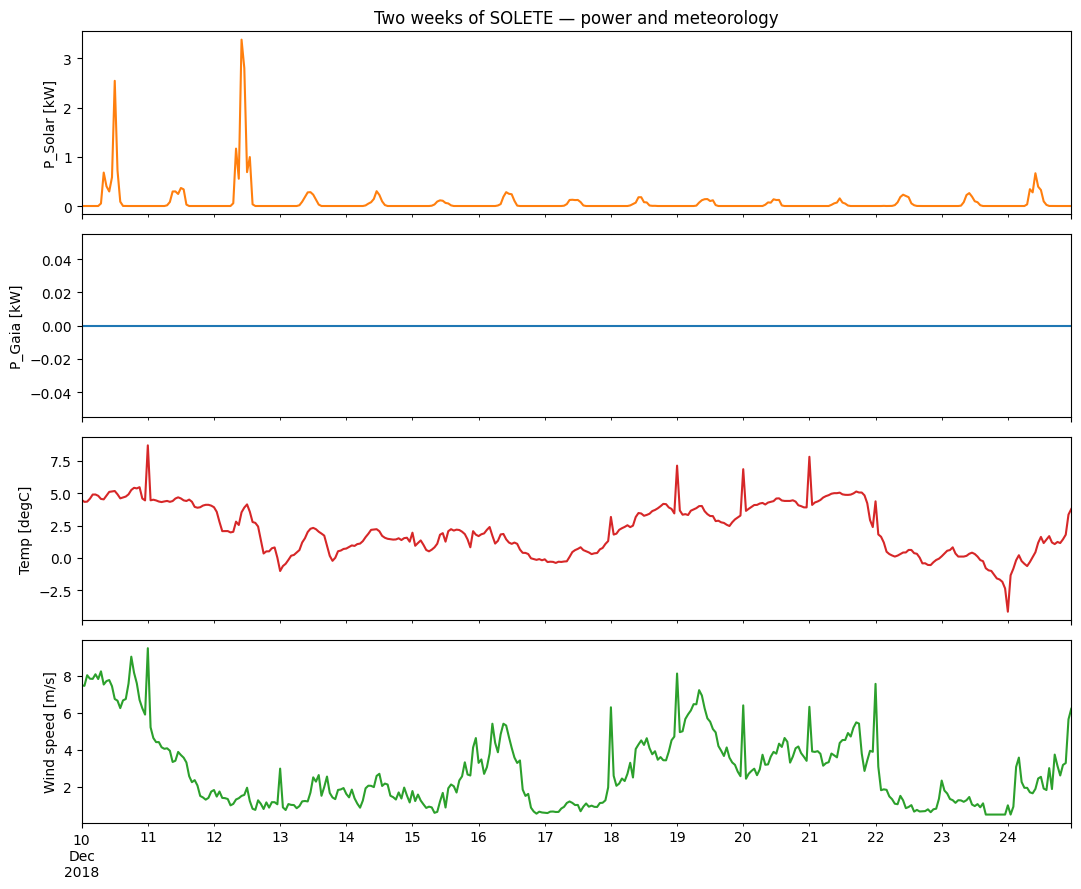

In [5]:
window = df.loc['2018-12-10':'2018-12-24']

fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)

window['P_Solar[kW]'].plot(ax=axes[0], color='tab:orange')
axes[0].set_ylabel('P_Solar [kW]')
axes[0].set_title('Two weeks of SOLETE — power and meteorology')

window['P_Gaia[kW]'].plot(ax=axes[1], color='tab:blue')
axes[1].set_ylabel('P_Gaia [kW]')

window['TEMPERATURE[degC]'].plot(ax=axes[2], color='tab:red')
axes[2].set_ylabel('Temp [degC]')

window['WIND_SPEED[m1s]'].plot(ax=axes[3], color='tab:green')
axes[3].set_ylabel('Wind speed [m/s]')
axes[3].set_xlabel('')

fig.tight_layout()
plt.show()

Notice the clear daily on/off pattern in `P_Solar[kW]` (no sun at night, of course),
while `P_Gaia[kW]` (wind) follows the wind speed instead and can produce at any hour.
Both are winter-Denmark values here — short days, modest solar output, occasional
decent wind.

## Next steps

- `02_data_quality.ipynb` — what the `_qc` flag columns mean, with real flagged rows
  from this same sample.
- `03_pv_forecasting.ipynb` / `04_wind_forecasting.ipynb` — simple forecasting demos
  built on top of what you just loaded.